In [1]:
## Here, we implement a Hopfield model for dynamical learning.
## Classification is performed by dynamically evolving the data, provided as initial conditions,
## toward the corresponding labels, implemented as crafted attractors in phase space.
## The learning process therefore consists of sculpting the basins of attraction of these attractors.

## If you use this code, please cite the following papers:

## Lorenzo Chicchi et al 2025 Mach. Learn.: Sci. Technol. 6 035054
## Stefano Gagliani et al 2026 Mach. Learn.: Sci. Technol. 7 025020

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def create_spiral_dataset(n_samples, noise=0.0, turns=0.5, radius=1.0, seed=None):
    rng = np.random.default_rng(seed)
    n0, n1 = n_samples // 2, n_samples - n_samples // 2
    Xs, ys = [], []

    while min(len(Xs), len(ys)) < max(n0, n1):
        r = radius * np.sqrt(rng.random(4 * n_samples))
        t = rng.uniform(0, 2*np.pi, 4 * n_samples)
        X = np.c_[r*np.cos(t), r*np.sin(t)]
        y = (np.cos(t - turns*2*np.pi*r/radius) < 0).astype(np.int64)

        if noise:
            X += rng.normal(0, noise, X.shape)

        Xs.extend(X[y == 0])
        ys.extend(X[y == 1])

    X = np.vstack([Xs[:n0], ys[:n1]]).astype(np.float32)
    y = np.r_[np.zeros(n0), np.ones(n1)].astype(np.int64)

    idx = rng.permutation(n_samples)
    return torch.tensor(X[idx]), torch.tensor(y[idx])

def embedding(x, dim=100):
    zeros = torch.zeros((x.shape[0], dim), dtype=x.dtype, device=x.device)
    return torch.cat([zeros, x], dim=1)

X_train, y_train = create_spiral_dataset(n_samples=1000, noise=0.0, turns=0.7)
X_test, y_test = create_spiral_dataset(n_samples=1000,noise=0.0,turns=0.7)

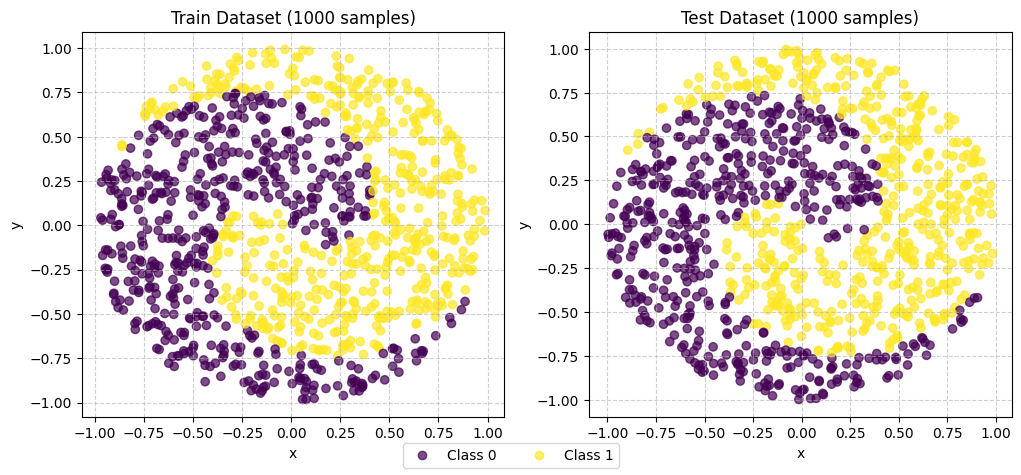

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
scatter_train = ax1.scatter(X_train[:, 0], X_train[:, 1], c=y_train, alpha=0.7)
ax1.set_title(f'Train Dataset ({len(X_train)} samples)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.grid(True, linestyle='--', alpha=0.6)
scatter_test = ax2.scatter(X_test[:, 0], X_test[:, 1], c=y_test,alpha=0.7)
ax2.set_title(f'Test Dataset ({len(X_test)} samples)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.grid(True, linestyle='--', alpha=0.6)
handles, _ = scatter_train.legend_elements()
fig.legend(handles, ['Class 0', 'Class 1'], loc='lower center', ncol=2)
plt.show()

In [5]:
N_computation = 98
N_read_out = 2
X_train = embedding(X_train, N_computation)
X_test = embedding(X_test, N_computation)

The Hopfield model equation reads:

$$
\dot{x}_i = -\alpha x_i + \beta \sum_j A_{ij} f(x_j) + b_i,
$$

where $x_i$ is the activity of neuron $i$, $f(x)$ is the nonlinear activation function, $A$ is the adjacency matrix connecting the neurons, $\alpha$ and $\beta$ are scalar parameters, and $b$ is a bias term.

The matrix $A$ is constructed in order to ensure that the labels are fixed points of the dynamics.
However, most of its entries remain free to be optimized during training. In particular we set:

$$
A = W (I - P) + \tilde{P},
$$

where

$$
P = \sum_{\ell}
\frac{|f(x^{\ell})\rangle \langle f(x^{\ell})|}
{\langle f(x^{\ell}) | f(x^{\ell}) \rangle},
$$

with the index $\ell$ running over the attractors, and

$$
\tilde{P} =
\frac{1}{\beta}
\sum_{\ell}
\frac{|\alpha x^{\ell} - b\rangle \langle f(x^{\ell})|}
{\langle f(x^{\ell}) | f(x^{\ell}) \rangle},
$$

with the entries of the matrix $W$ trainable parameters that can be freely optimized.

By choosing $x^{\ell}$ and $f(x^{\ell})$ to be mutually orthogonal, and by substituting $P$ and $\tilde{P}$ into the Hopfield equation, we obtain

$$
\dot{x}^{\ell} = 0
\qquad \forall \, \ell.
$$
Indeed, evaluating $\dot{x}$ at a particular attractor $x^k$,
$$
-\alpha x^k + \beta \left(W(I-P) + \tilde{P} \right) f(x^k) + b=0,
$$

since
$$
(I-P)|f(x^k)\rangle = |f(x^k)\rangle - |f(x^k)\rangle = 0,
$$

and
$$
\tilde{P}|f(x^k)\rangle = \frac{\alpha x^k - b}{\beta}.
$$

In [6]:
class HopfieldModel(nn.Module):
    def __init__(self, n_total, n_output, beta=0.1, alpha=1.0, attractor_value=1., bias_flag=True):
        super().__init__()
        self.n_output = n_output
        self.bias_flag = bias_flag
        self.n_total = n_total
        self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float32))
        self.register_buffer('beta', torch.tensor(beta, dtype=torch.float32))
        self.register_buffer('c', torch.tensor(1.0 / 8.0, dtype=torch.float32))

        ## Trainable weights
        self.W = nn.Parameter(torch.empty(self.n_total, self.n_total))
        nn.init.kaiming_normal_(self.W)
        if self.bias_flag:
            self.bias = nn.Parameter(torch.zeros(self.n_total, dtype=torch.float32))
        else:
            self.register_buffer('bias', torch.zeros(self.n_total, dtype=torch.float32))

        ## Build attractors, they must be orthogonal!
        x_attractors = torch.zeros(self.n_total, self.n_output, dtype=torch.float32)
        x_attractors[0, 0] = attractor_value
        x_attractors[1, 1] = attractor_value
        fx_attractors = self.activation_function(x_attractors)

        norm_fx_attr = torch.sum(fx_attractors ** 2, dim=0, keepdim=True)
        normalized_fx_attr = fx_attractors / norm_fx_attr

        ## Projector P = \sum_{attractors} |f(x)><f(x)| / <f(x)|f(x)>
        P = fx_attractors @ normalized_fx_attr.t()
        self.register_buffer('P', P)
        self.register_buffer('I_minus_P', torch.eye(self.n_total, dtype=torch.float32) - P)

        ## Store necessary components to build P_tilde dynamically
        ## P_tilde = 1 /beta \sum_{attractors} |(alpha * x - bias)><f(x)| / <f(x)|f(x)>
        self.register_buffer('x_attractors', x_attractors)
        self.register_buffer('fx_attractors', fx_attractors)
        self.register_buffer('norm_fx_attr', norm_fx_attr)
        self.register_buffer('normalized_fx_attr', normalized_fx_attr)
        self.register_buffer('attractor_1', x_attractors[:, 0])
        self.register_buffer('attractor_2', x_attractors[:, 1])
        self.register_buffer('sigma_a1', fx_attractors[:, 0])
        self.register_buffer('sigma_a2', fx_attractors[:, 1])


    def activation_function(self, x):
        ## With this activation function we can compute the stability of the attractors analytically.
        return x**2/(self.c + x**2)

    def adjacency_matrix(self):
        ## --- Dynamically Construct P_tilde ---
        ## The ket must be (alpha * a - bias) / beta to ensure x_dot = 0 at the attractor.
        P_tilde = ((self.alpha * self.x_attractors - self.bias.unsqueeze(1)) @ self.normalized_fx_attr.t()) / self.beta
        ## Construct the adjacency matrix A
        A = torch.matmul(self.W, self.I_minus_P) + P_tilde
        return A

    def drift(self, x, A=None):
        if A is None:
            A = self.adjacency_matrix()
        ## Hopfield velocity field
        network_input = torch.matmul(self.activation_function(x), A.t())
        x_dot = -self.alpha * x + self.beta * network_input + self.bias
        return x_dot

    def forward(self, x_input, num_steps, dt, return_trajectory=True):
        x = x_input
        A = self.adjacency_matrix()
        if return_trajectory:
            trajectory = [x]
        for _ in range(num_steps):
            x = x + self.drift(x, A=A) * dt
            if return_trajectory:
                trajectory.append(x)
        if return_trajectory:
            return x, torch.stack(trajectory, dim=1)  # Shape: (batch_size, num_steps + 1, n_total)
        return x, None

    def predict(self, x_input, num_steps, dt):
        """
        Runs the forward integration and strictly returns the predicted
        class labels based on the minimum distance to the attractors.
        """
        with torch.no_grad():
            final_state, _ = self.forward(x_input, num_steps, dt, return_trajectory=False)

            dist_to_a1 = torch.sum((final_state - self.attractor_1) ** 2, dim=1)
            dist_to_a2 = torch.sum((final_state - self.attractor_2) ** 2, dim=1)

            predictions = torch.where(dist_to_a1 < dist_to_a2, 0, 1)
            return predictions

    def activation_derivative(self, x):
        ## Derivative of the activation function f(x) = x^2 / (c + x^2) needed for Jacobian computation
        return 2 * self.c * x / (self.c + x**2)**2

    def jacobian_eigvals(self, attractor_index=0, plot_flag=False, dt=None, return_jacobian=False):
        ## Compute the Jacobian eigenvalues at a given attractor
        A = self.adjacency_matrix()

        x_star = self.x_attractors[:, attractor_index].to(device=A.device, dtype=A.dtype)
        I = torch.eye(self.n_total, device=A.device, dtype=A.dtype)

        with torch.enable_grad():
            D_fx = torch.diag(self.activation_derivative(x_star))

        with torch.no_grad():
            ## Jacobian of x_dot = -alpha*x + beta*A*f(x) + bias
            J = -self.alpha * I + self.beta * A @ D_fx

            eigvals = torch.linalg.eigvals(J)

            if plot_flag:
                eig_np = eigvals.detach().cpu().numpy()

                plt.figure(figsize=(6, 5))
                plt.scatter(eig_np.real, eig_np.imag, alpha=0.8)
                plt.axvline(0.0, linestyle='--', linewidth=1)
                plt.axhline(0.0, linestyle='--', linewidth=1)
                plt.xlabel('Real part')
                plt.ylabel('Imaginary part')
                plt.title(f'Jacobian eigenvalues at attractor {attractor_index}')
                plt.grid(True, linestyle='--', alpha=0.6)
                plt.show()

                print("Max real eigenvalue:", eigvals.real.max().item())

                if dt is not None:
                    print("Max abs Euler eigenvalue:", torch.abs(1.0 + dt * eigvals).max().item())

            if return_jacobian:
                return eigvals, J

            return eigvals

In [7]:
## Training
N_IN = 2
N_HIDDEN = N_computation - N_read_out
N_OUT = N_read_out
DT = 0.03
STEPS = 200
EPOCHS = 100
BATCH_SIZE = 256
total_neurons = N_HIDDEN + N_IN + N_OUT
model = HopfieldModel(n_total=total_neurons, n_output=N_OUT)

In [8]:
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

print("Starting training...\n")
loss_history = []

all_attractors = model.x_attractors.t()

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    permutation = torch.randperm(X_train.size(0))

    for i in range(0, X_train.size(0), BATCH_SIZE):
        optimizer.zero_grad()

        indices = permutation[i:i+BATCH_SIZE]
        batch_x, batch_y = X_train[indices], y_train[indices]

        final_state, _ = model(batch_x, num_steps=STEPS, dt=DT, return_trajectory=False)

        targets = all_attractors[batch_y]

        loss = criterion(final_state, targets)
        loss.backward()

        optimizer.step()
        epoch_loss += loss.item() * batch_x.size(0)

    avg_loss = epoch_loss / X_train.size(0)
    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        model.eval()
        predictions = model.predict(X_test, num_steps=STEPS, dt=DT)
        accuracy = (predictions == y_test).float().mean().item() * 100.0
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}] | MSE Loss: {avg_loss:.6f} | Test Accuracy: {accuracy:.2f}%")

print("\nTraining Complete!")

Starting training...

Epoch [  1/100] | MSE Loss: 0.009641 | Test Accuracy: 50.00%
Epoch [ 10/100] | MSE Loss: 0.003702 | Test Accuracy: 74.00%
Epoch [ 20/100] | MSE Loss: 0.003573 | Test Accuracy: 73.10%
Epoch [ 30/100] | MSE Loss: 0.003480 | Test Accuracy: 73.90%
Epoch [ 40/100] | MSE Loss: 0.003338 | Test Accuracy: 75.20%
Epoch [ 50/100] | MSE Loss: 0.003224 | Test Accuracy: 77.80%
Epoch [ 60/100] | MSE Loss: 0.003033 | Test Accuracy: 79.60%
Epoch [ 70/100] | MSE Loss: 0.002801 | Test Accuracy: 80.70%
Epoch [ 80/100] | MSE Loss: 0.002765 | Test Accuracy: 82.40%
Epoch [ 90/100] | MSE Loss: 0.002291 | Test Accuracy: 88.00%
Epoch [100/100] | MSE Loss: 0.001807 | Test Accuracy: 92.20%

Training Complete!


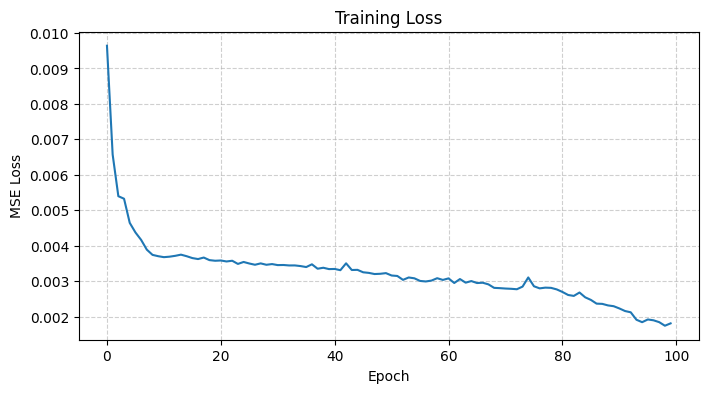

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [10]:
print("\nEvaluating on Test Dataset...")
model.eval()

predictions = model.predict(X_test, num_steps=STEPS, dt=DT)

correct = (predictions == y_test).sum().item()
total = y_test.size(0)
accuracy = (correct / total) * 100.0

print(f"Test Accuracy: {accuracy:.2f}% ({correct}/{total} correct)")

with torch.no_grad():
    final_state, _ = model(X_test, num_steps=STEPS, dt=DT, return_trajectory=False)
    dist_to_a1 = torch.sum((final_state - model.attractor_1) ** 2, dim=1)
    dist_to_a2 = torch.sum((final_state - model.attractor_2) ** 2, dim=1)


Evaluating on Test Dataset...
Test Accuracy: 92.20% (922/1000 correct)


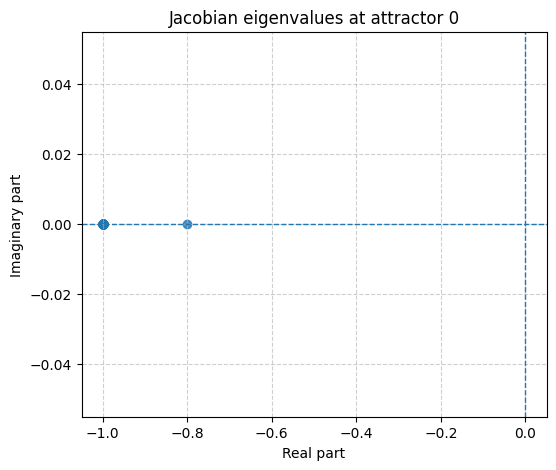

Max real eigenvalue: -0.8003509640693665
Max abs Euler eigenvalue: 0.9759894609451294


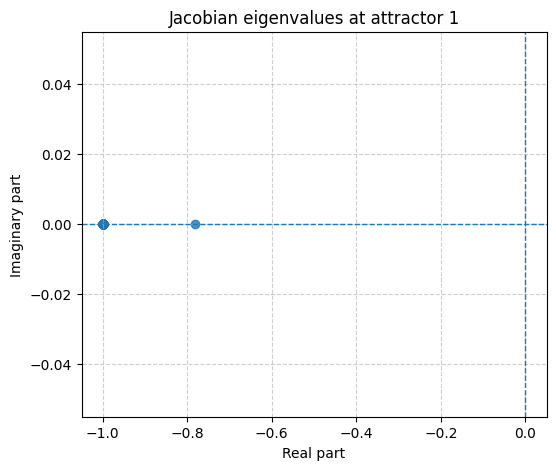

Max real eigenvalue: -0.7804661989212036
Max abs Euler eigenvalue: 0.9765859842300415


In [11]:
eigvals_1 = model.jacobian_eigvals(attractor_index=0, plot_flag=True, dt=DT)
eigvals_2 = model.jacobian_eigvals(attractor_index=1, plot_flag=True, dt=DT)